## Setup

In [1]:
from pathlib import Path
import sys

# path shenanigans to make relative imports work
sys.path.insert(0, str(Path.cwd().parent))

In [2]:
import pandas as pd
from tqdm.auto import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
from analysis.analysis_helpers import analyze_centrality
from ipysigma import Sigma
import networkx as nx

tqdm.pandas()

In [3]:
import importlib
import analysis.helpers as h

importlib.reload(h)

<module 'analysis.helpers' from 'c:\\Users\\Kalami\\Desktop\\Programs\\University\\Master\\Dissertation\\project\\analysis\\helpers.py'>

## Old Data Loading + Embedding Creation

In [5]:
df = pd.read_csv("../outputs/hu_2017.csv")

,Speaker_ID,Date,ID,Text_ID,Title,Body,Term,Session,Meeting,Sitting,...,Party_status,Party_orientation,Speaker_name,Speaker_gender,Speaker_birth,Topic,Text,Full_text,label,score
0,AghPeter,2020-02-17,u2020-02-17-179-1,ParlaMint-HU_2020-02-17,"Hungarian parliamentary corpus ParlaMint-HU, l...",Unicameralism,8. ciklus,-,37. ülés,1. ülésnap,...,Coalition,Right to far-right,"Ágh, Péter",M,1982,Housing,Tisztelt Államtitkár Úr!,Tisztelt Államtitkár Úr! Magyarország Kormánya...,NEUTRAL,0.969221
1,AghPeter,2020-02-17,u2020-02-17-179-10,ParlaMint-HU_2020-02-17,"Hungarian parliamentary corpus ParlaMint-HU, l...",Unicameralism,8. ciklus,-,37. ülés,1. ülésnap,...,Coalition,Right to far-right,"Ágh, Péter",M,1982,Housing,"Emellett orvosi eszközök, falubuszok, közterül...",Tisztelt Államtitkár Úr! Magyarország Kormánya...,NEUTRAL,0.979289
2,AghPeter,2020-02-17,u2020-02-17-179-11,ParlaMint-HU_2020-02-17,"Hungarian parliamentary corpus ParlaMint-HU, l...",Unicameralism,8. ciklus,-,37. ülés,1. ülésnap,...,Coalition,Right to far-right,"Ágh, Péter",M,1982,Housing,"Látható, hogy az egyes alprogramok összefüggne...",Tisztelt Államtitkár Úr! Magyarország Kormánya...,NEUTRAL,0.985055
3,AghPeter,2020-02-17,u2020-02-17-179-12,ParlaMint-HU_2020-02-17,"Hungarian parliamentary corpus ParlaMint-HU, l...",Unicameralism,8. ciklus,-,37. ülés,1. ülésnap,...,Coalition,Right to far-right,"Ágh, Péter",M,1982,Housing,"Az érdeklődés óriási, a tapasztalatok jók, nek...",Tisztelt Államtitkár Úr! Magyarország Kormánya...,NEUTRAL,0.983033
4,AghPeter,2020-02-17,u2020-02-17-179-13,ParlaMint-HU_2020-02-17,"Hungarian parliamentary corpus ParlaMint-HU, l...",Unicameralism,8. ciklus,-,37. ülés,1. ülésnap,...,Coalition,Right to far-right,"Ágh, Péter",M,1982,Housing,A megvalósult fejlesztések mind az adott falut...,Tisztelt Államtitkár Úr! Magyarország Kormánya...,NEUTRAL,0.983119


In [ ]:
# TODO: Add helper-based embedding
df = create_embeddings(df)

## Data Loading

In [4]:
# get the embeddings back
df = h.load_data("2020")

In [5]:
df[["Speaker_party", "Party_status"]].drop_duplicates()

,,,Speaker_party,Party_status
Speaker_ID,Date,ID,,
AghPeter,2020-02-17,u2020-02-17-179-1,Fidesz-frakció,Coalition
AnderBalazs,2020-02-17,u2020-02-17-141-1,JOBBIK-frakció,Opposition
ApatiIstvan,2020-02-17,u2020-02-17-241-1,Mi Hazánk,-
AradszkiAndras,2020-02-17,u2020-02-17-65-1,KNDP-frakció,Coalition
AratoGergely,2020-02-17,u2020-02-17-103-1,DK-frakció,Opposition
BanaTibor,2020-03-24,u2020-03-24-125-1,-,-
BangoneBorbelyIldiko,2020-02-24,u2020-02-24-13-1,MSZP-frakció,Opposition
BuranySandor,2020-02-20,u2020-02-20-1-1,Párbeszéd-frakció,Opposition
CsardiAntal,2020-02-17,u2020-02-17-171-1,LMP-frakció,Opposition


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 143579 entries, ('AghPeter', Timestamp('2020-02-17 00:00:00'), 'u2020-02-17-179-1') to ('ZsigoRobert', Timestamp('2020-11-30 00:00:00'), 'u2020-11-30-348-9')
Data columns (total 27 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Unnamed: 0          143579 non-null  int64  
 1   Text_ID             143579 non-null  object 
 2   Title               143579 non-null  object 
 3   Body                143579 non-null  object 
 4   Term                143579 non-null  object 
 5   Session             143579 non-null  object 
 6   Meeting             143579 non-null  object 
 7   Sitting             143579 non-null  object 
 8   Agenda              143579 non-null  object 
 9   Subcorpus           143579 non-null  object 
 10  Lang                143579 non-null  object 
 11  Speaker_role        143579 non-null  object 
 12  Speaker_MP          143579 non-null  bool   
 13  Spea

In [6]:
df.columns

Index(['Unnamed: 0', 'Text_ID', 'Title', 'Body', 'Term', 'Session', 'Meeting',
       'Sitting', 'Agenda', 'Subcorpus', 'Lang', 'Speaker_role', 'Speaker_MP',
       'Speaker_minister', 'Speaker_party', 'Speaker_party_name',
       'Party_status', 'Party_orientation', 'Speaker_name', 'Speaker_gender',
       'Speaker_birth', 'Topic', 'Text', 'Full_text', 'label', 'score',
       'embedding', 'speaker_party_simple'],
      dtype='object')

In [ ]:
df["Party_orientation"].unique()

array(['Right to far-right', 'Centre-right', 'Far-right', 'Right',
       'Centre-left', '-', 'Centre-left to left', 'Centre to centre-left'],
      dtype=object)

In [ ]:
parties = list(df["Speaker_party"].unique())
for i, party_name in enumerate(parties):
    for j in range(i + 1, len(parties)):
        seta = set(df[df["Speaker_party"] == party_name].index.get_level_values(0))
        setb = set(df[df["Speaker_party"] == parties[j]].index.get_level_values(0))

        if len(seta & setb) > 0:
            print(party_name, parties[j], seta & setb)

JOBBIK-frakció - {'SneiderTamas', 'VargaDammAndrea', 'BanaTibor', 'FarkasGergely'}
- Fidesz {'MenczerTamas'}
- Volner {'VolnerJanos'}


In [27]:
set(df[df["Speaker_party"] == "Fidesz"].index.get_level_values(0))

{'CsengerZalanZsolt', 'MenczerTamas', 'OrbanBalazs'}

In [ ]:
for label in ["PRO", "CONTRA", "NEUTRAL"]:
    n = len(df[df["label"] == label])
    print(f"Number of {label} entries: {n}, {n / len(df)}")

Number of PRO entries: 25206, 0.1755549209842665
Number of CONTRA entries: 20010, 0.13936578468996164
Number of NEUTRAL entries: 98363, 0.6850792943257719


In [12]:
print(len(df))

143579


## Network Setup

In [7]:
# extract the correct data from a timeframe
start = pd.Timestamp(year=2020, month=3, day=1)
end = pd.Timestamp(year=2021, month=1, day=1)

graphs, combined_data = h.build_graphs(
    df, start, end, pd.offsets.MonthBegin(1), pd.offsets.MonthEnd(0)
)

Graph created for period 2020-04-01 00:00:00-2020-04-30 00:00:00
Graph created for period 2020-05-01 00:00:00-2020-05-31 00:00:00
Graph created for period 2020-06-01 00:00:00-2020-06-30 00:00:00
Graph created for period 2020-07-01 00:00:00-2020-07-31 00:00:00
Graph created for period 2020-08-01 00:00:00-2020-08-31 00:00:00
Graph created for period 2020-09-01 00:00:00-2020-09-30 00:00:00
Graph created for period 2020-10-01 00:00:00-2020-10-31 00:00:00
Graph created for period 2020-11-01 00:00:00-2020-11-30 00:00:00
Graph created for period 2020-12-01 00:00:00-2020-12-31 00:00:00
Graph created for period 2021-01-01 00:00:00-2021-01-31 00:00:00


In [8]:
combined_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 976 entries, 0 to 975
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   month               976 non-null    int64  
 1   Speaker_name        976 non-null    object 
 2   Party_orientation   976 non-null    object 
 3   Party_status        976 non-null    object 
 4   Speaker_party       976 non-null    object 
 5   Speaker_party_name  976 non-null    object 
 6   Speaker_minister    976 non-null    bool   
 7   Speaker_MP          976 non-null    bool   
 8   opinion             976 non-null    float64
 9   opinion_color       976 non-null    object 
 10  nr_speeches         976 non-null    int64  
 11  orientation_simple  976 non-null    object 
 12  degree              976 non-null    int64  
 13  degree_centrality   976 non-null    float64
 14  betweenness         976 non-null    float64
 15  pagerank            976 non-null    float64
 16  eigenvec

## Network Visualizations

#### Sigma

In [7]:
G, sim_matrix, metrics, data = [
    (r["graph"], r["sim_matrix"], r["metrics"], r["data"])
    for r in graphs
    if r["graph"] is not None
][3]

Text(0.991, 530, 'Edge Creation Threshold')

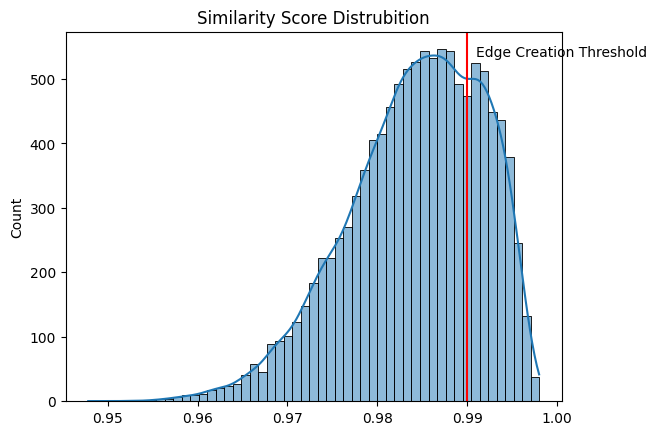

In [ ]:
# extract similarity scores
sim_flattened = []
for i in range(len(sim_matrix)):
    for j in range(i + 1, len(sim_matrix[i])):
        sim_flattened.append(sim_matrix[i, j])

# plot the distribution
ax = sns.histplot(data=sim_flattened, kde=True)

ax.axvline(0.99, linestyle="-", c="red")
ax.set_title("Similarity Score Distrubition")
ax.text(x=0.99, y=530, s="Edge Creation Threshold", ha="right")

In [9]:
Sigma(
    G,
    node_size="degree_centrality",
    raw_node_color="opinion_color",
    node_border_color="Party_status",
    edge_size="weight",
    default_node_border_size=6,
)

Sigma(nx.Graph with 151 nodes and 2,924 edges)

#### Seaborn

In [15]:
combined_data.columns

Index(['month', 'Speaker_name', 'Party_orientation', 'Party_status',
       'Speaker_party', 'Speaker_party_name', 'Speaker_minister', 'Speaker_MP',
       'aggregated_embedding', 'opinion', 'opinion_color', 'nr_speeches',
       'orientation_simple'],
      dtype='object')

<Axes: xlabel='month', ylabel='opinion'>

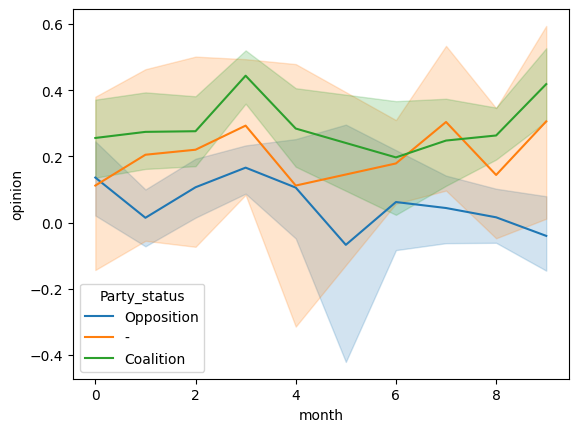

In [9]:
sns.lineplot(combined_data, x="month", y="opinion", hue="Party_status")

<Axes: xlabel='month', ylabel='opinion'>

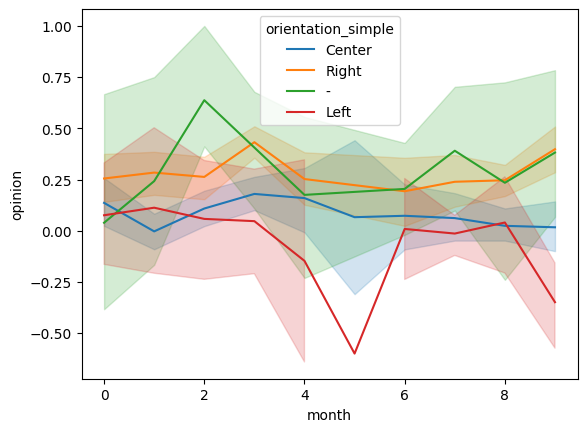

In [ ]:
sns.lineplot(combined_data, x="month", y="opinion", hue="orientation_simple")

<Axes: xlabel='month', ylabel='opinion'>

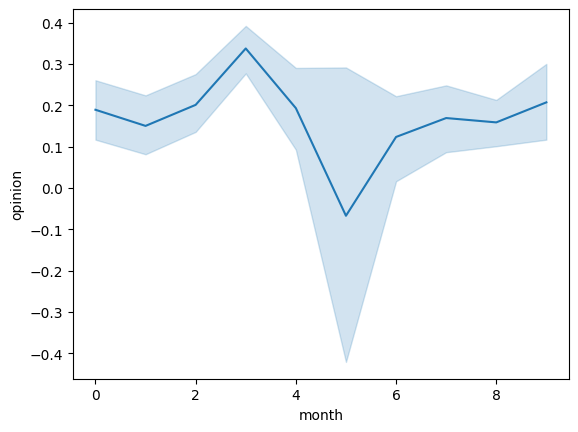

In [ ]:
sns.lineplot(combined_data, x="month", y="opinion")

Text(0.21928488560743098, 120, 'Average: 0.20')

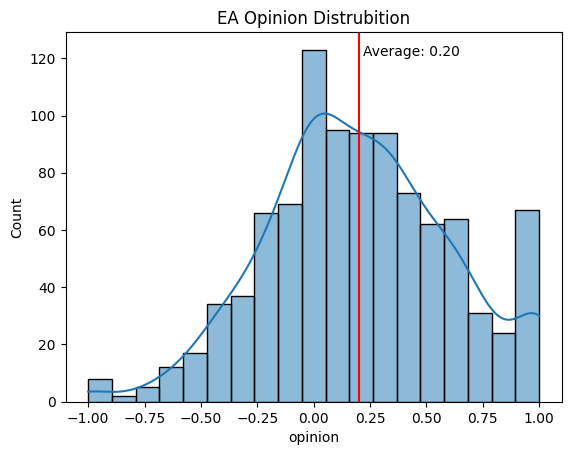

In [22]:
ax = sns.histplot(data=combined_data, x="opinion", kde=True)
mean = combined_data["opinion"].mean()

ax.axvline(mean, linestyle="-", c="red")
ax.set_title("EA Opinion Distrubition")
ax.text(x=mean * 1.1, y=120, s=f"Average: {mean:.2f}", va="bottom")

Text(0, 0.5, 'Value')

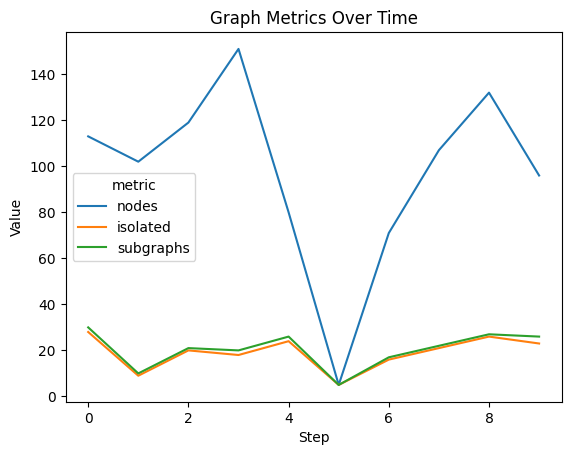

In [29]:
data = []

for i, graph_data in enumerate(graphs):
    g = graph_data["graph"]

    data.append(
        {
            "step": i,
            "nodes": g.number_of_nodes(),
            "edges": g.number_of_edges(),
            "isolated": len(list(nx.isolates(g))),
            "subgraphs": nx.number_connected_components(g),
        }
    )

df_data = pd.DataFrame(data)

df_melted = df_data.melt(
    id_vars="step",
    value_vars=["nodes", "isolated", "subgraphs"],
    var_name="metric",
    value_name="value",
)

sns.lineplot(data=df_melted, x="step", y="value", hue="metric")

plt.title("Graph Metrics Over Time")
plt.xlabel("Step")
plt.ylabel("Value")

Text(0, 0.5, 'Value')

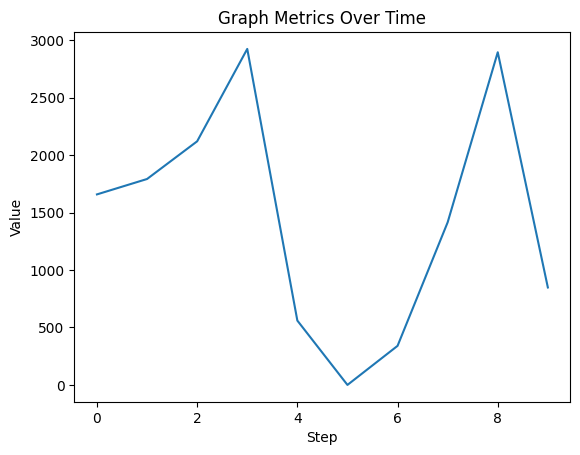

In [30]:
sns.lineplot(data=df_data, x="step", y="edges")

plt.title("Graph Metrics Over Time")
plt.xlabel("Step")
plt.ylabel("Value")

In [126]:
analyze_centrality(G, "Graph")

                            Centrality measures of the largest connected component of Graph                            
           Degree            |         Betweenness         |          Closeness          |         Eigenvector         
  (NacsaLorinc)   - 0.753846 |  (NacsaLorinc)   - 0.058725 |  (NacsaLorinc)   - 0.783133 |  (NacsaLorinc)   - 0.133680
  (BoroczLaszlo)  - 0.707692 |  (VargaMihaly)   - 0.047729 |  (BoroczLaszlo)  - 0.751445 |  (BoroczLaszlo)  - 0.132314
  (OrbanBalazs)   - 0.684615 |   (SzucsLajos)   - 0.042853 |   (BankiErik)    - 0.747126 |  (OrbanBalazs)   - 0.131290
   (BankiErik)    - 0.676923 |  (FoldiLaszlo)   - 0.041887 |  (OrbanBalazs)   - 0.738636 | (VargaDammAndrea) - 0.131011
  (FoldiLaszlo)   - 0.653846 |   (BankiErik)    - 0.041055 |  (FoldiLaszlo)   - 0.734463 | (HarangozoTamas) - 0.130807
 (HarangozoTamas) - 0.653846 |   (NagyCsaba)    - 0.036385 | (HarangozoTamas) - 0.722222 | (LukacsLaszloGyorgy) - 0.130532



In [132]:
list(metrics.keys())

['degree',
 'degree_centrality',
 'betweenness',
 'pagerank',
 'eigenvector',
 'communities',
 'modularity']

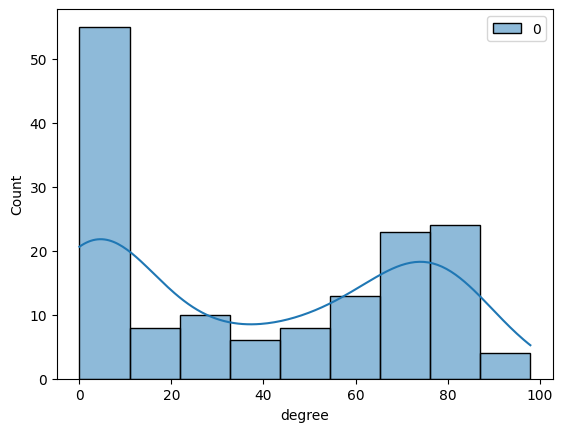

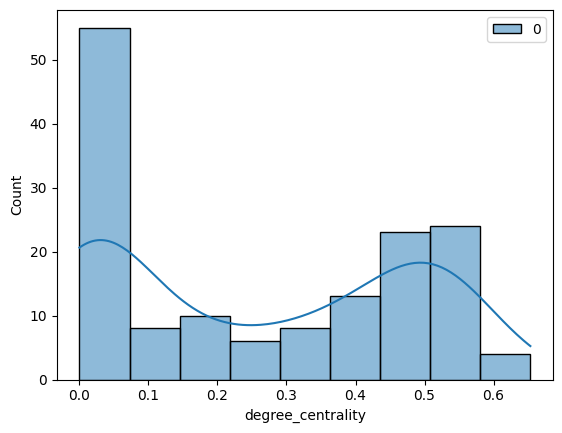

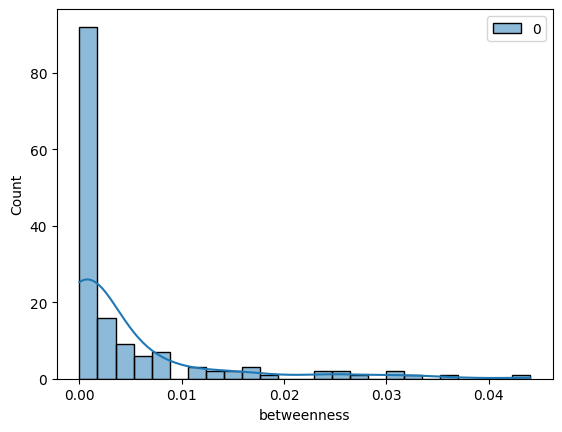

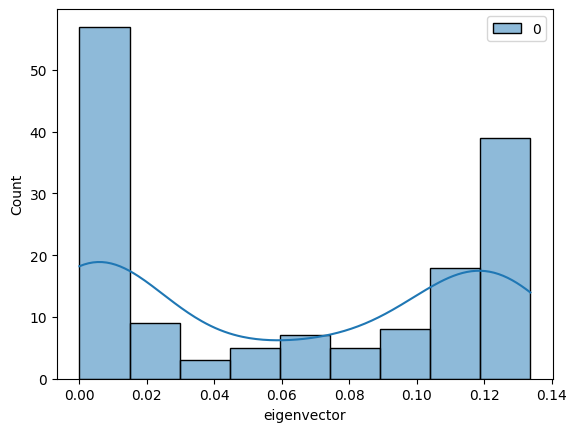

In [137]:
# get a few distributions of centralities
metric_names = ["degree", "degree_centrality", "betweenness", "eigenvector"]
for metric_name in metric_names:
    ax = sns.histplot(data=metrics[metric_name].values(), kde=True)
    ax.set(xlabel=metric_name)
    plt.show()

In [ ]:
community_sets = [set() for _ in range(max(metrics["communities"].values()))]
for key in metrics["communities"]:
    community_sets[metrics["communities"][key]].add(key)

[set(),
 set(),
 set(),
 set(),
 set(),
 set(),
 set(),
 set(),
 set(),
 set(),
 set(),
 set(),
 set(),
 set(),
 set(),
 set(),
 set(),
 set(),
 set(),
 set(),
 set(),
 set()]